In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import scipy.stats as stats

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Building a Basic VAE in PyTorch

In [3]:
BATCH_SIZE = 128
EPOCHS = 15
LEARNING_RATE = 1e-3
LATENT_DIM = 20  # Dimensionality of the latent space (z)

In [4]:
# MNIST images are 1x28x28. We convert them to tensors which scale pixels to [0, 1].
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 36.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 894kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.78MB/s]


In [5]:
# --- VAE Model Architecture ---
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        
        # ENCODER (784 -> 400 -> Latent)
        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, LATENT_DIM)  # Outputs mean (mu)
        self.fc22 = nn.Linear(400, LATENT_DIM)  # Outputs log-variance (log_var)
        
        # DECODER (Latent -> 400 -> 784)
        self.fc3 = nn.Linear(LATENT_DIM, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, log_var):
        """
        Reparameterization trick: z = mu + sigma * epsilon
        We use exp(0.5 * log_var) to get standard deviation (sigma).
        """
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std) # Sample epsilon ~ N(0, I)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        # Use sigmoid to ensure output is in [0, 1], representing Bernoulli probabilities
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        # Flatten the 28x28 image into a 784 vector
        x = x.view(-1, 784)
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recon_x = self.decode(z)
        return recon_x, mu, log_var

In [6]:
# --- Loss Function (Negative ELBO) ---
def vae_loss_function(recon_x, x, mu, log_var):
    # Flatten input to match recon_x
    x_flat = x.view(-1, 784)
    
    # 1. Reconstruction Loss (Binary Cross Entropy)
    # reduction='sum' sums over the batch and pixel dimensions
    BCE = F.binary_cross_entropy(recon_x, x_flat, reduction='sum')
    
    # 2. KL Divergence
    # Closed form: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    # Note: log_var.exp() is sigma^2
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    return BCE + KLD

In [7]:
# --- Training Loop ---
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Starting VAE Training...")
model.train()

for epoch in range(1, EPOCHS + 1):
    train_loss = 0
    
    # Progress bar for the batches
    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)
    for batch_idx, (data, _) in enumerate(loop):
        data = data.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        recon_batch, mu, log_var = model(data)
        
        # Calculate loss
        loss = vae_loss_function(recon_batch, data, mu, log_var)
        
        # Backward pass and optimize
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
        # Update progress bar
        loop.set_postfix(loss=loss.item() / len(data))
    
    # Print average loss for the epoch
    avg_loss = train_loss / len(train_loader.dataset)
    print(f"Epoch {epoch} complete! Average Loss (Negative ELBO): {avg_loss:.4f}")

print("Training finished!")

Starting VAE Training...


Epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1 complete! Average Loss (Negative ELBO): 165.7979


Epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2 complete! Average Loss (Negative ELBO): 121.9434


...

Epoch 13 complete! Average Loss (Negative ELBO): 105.3471


Epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 14 complete! Average Loss (Negative ELBO): 105.1276


Epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 15 complete! Average Loss (Negative ELBO): 104.8741
Training finished!


## Analyzing VAE Performance

In [8]:
# --- Setup Test Data ---
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
# We will use 2000 samples for the latent space visualization to keep t-SNE fast
test_loader = DataLoader(test_dataset, batch_size=2000, shuffle=True)

# Get a batch of data
data_iter = iter(test_loader)
images, labels = next(data_iter)
images = images.to(device)

model.eval() # Ensure model is in evaluation mode

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc21): Linear(in_features=400, out_features=20, bias=True)
  (fc22): Linear(in_features=400, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_58/3367797509.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.title("VAE Latent Space (t-SNE projection of $\mu$)")


Extracting latent means and running t-SNE...


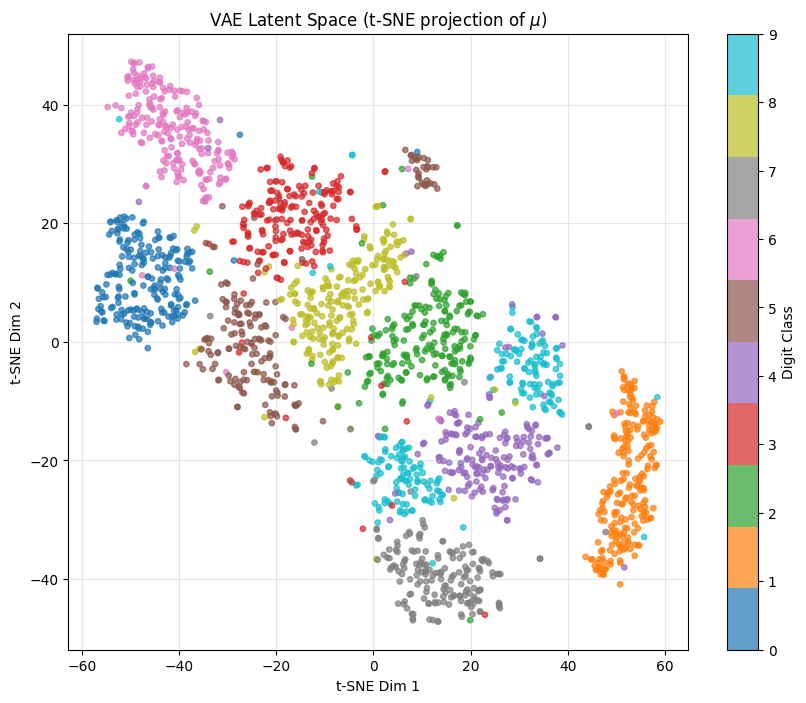


Generating Reconstructions...


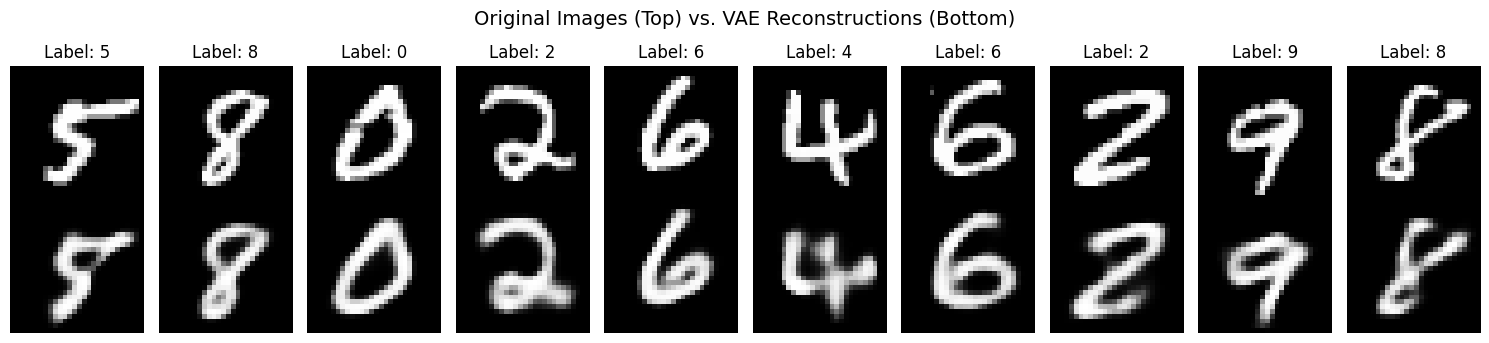


Generating New Digits from Random Noise...


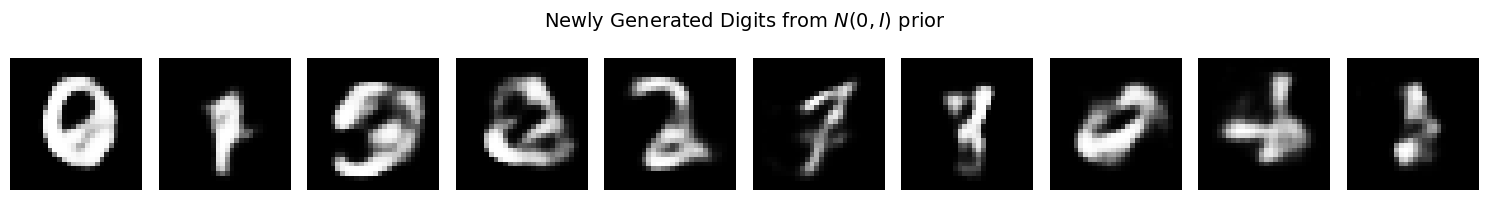

In [9]:
with torch.no_grad():
    # --- (a) Latent Space Visualization ---
    print("Extracting latent means and running t-SNE...")
    # Flatten images and pass through encoder to get the mean (mu)
    images_flat = images.view(-1, 784)
    mu, log_var = model.encode(images_flat)
    
    # Run t-SNE to reduce from 20D to 2D
    tsne = TSNE(n_components=2, random_state=42)
    mu_2d = tsne.fit_transform(mu.cpu().numpy())
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(mu_2d[:, 0], mu_2d[:, 1], c=labels.numpy(), cmap='tab10', alpha=0.7, s=15)
    plt.colorbar(scatter, ticks=range(10), label='Digit Class')
    plt.title("VAE Latent Space (t-SNE projection of $\mu$)")
    plt.xlabel("t-SNE Dim 1")
    plt.ylabel("t-SNE Dim 2")
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- (b) Reconstruction Quality ---
    print("\nGenerating Reconstructions...")
    # Take the first 10 images from our batch
    sample_images = images[:10]
    sample_labels = labels[:10]
    
    # Run through the full VAE
    reconstructed, _, _ = model(sample_images)
    
    # Reshape back to 28x28 for plotting
    sample_images = sample_images.cpu().view(-1, 28, 28).numpy()
    reconstructed = reconstructed.cpu().view(-1, 28, 28).numpy()
    
    fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
    fig.suptitle("Original Images (Top) vs. VAE Reconstructions (Bottom)", fontsize=14)
    
    for i in range(10):
        # Top row: Originals
        axes[0, i].imshow(sample_images[i], cmap='gray')
        axes[0, i].set_title(f"Label: {sample_labels[i].item()}")
        axes[0, i].axis('off')
        
        # Bottom row: Reconstructions
        axes[1, i].imshow(reconstructed[i], cmap='gray')
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()

    # --- (c) Generation of New Samples ---
    print("\nGenerating New Digits from Random Noise...")
    # Sample 10 random vectors from the prior N(0, I)
    # Shape: (10, LATENT_DIM) -> (10, 20)
    random_z = torch.randn(10, LATENT_DIM).to(device)
    
    # Pass through the decoder
    generated_images = model.decode(random_z)
    generated_images = generated_images.cpu().view(-1, 28, 28).numpy()
    
    fig, axes = plt.subplots(1, 10, figsize=(15, 2))
    fig.suptitle(f"Newly Generated Digits from $N(0, I)$ prior", fontsize=14)
    
    for i in range(10):
        axes[i].imshow(generated_images[i], cmap='gray')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

## Additional Diagrams

Generating Latent Space Interpolation...


<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_58/1853436776.py:37: SyntaxWarning: invalid escape sequence '\m'
  plt.hist(mu_flat, bins=60, density=True, alpha=0.6, color='royalblue', label="VAE Latent Means ($\mu$)")
/tmp/ipykernel_58/1853436776.py:41: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Checking KL Divergence: Does $\mu$ match $N(0,1)$?")


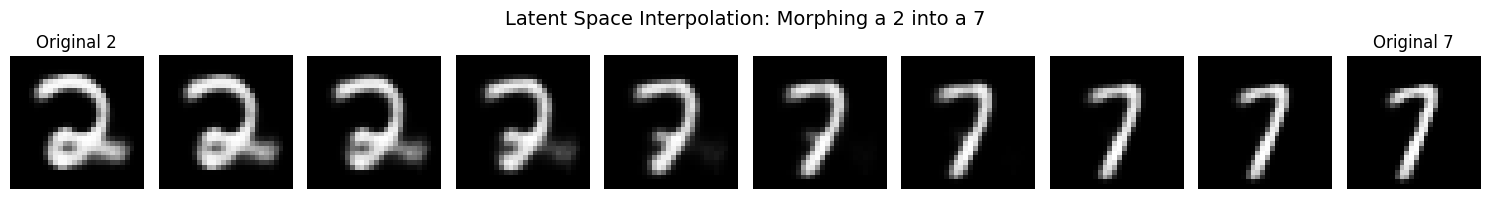


Plotting Latent Distribution Check...


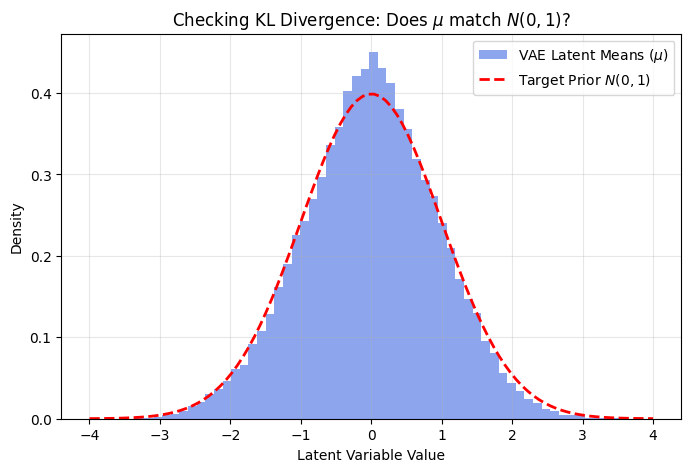

In [10]:
model.eval()
with torch.no_grad():
    # Latent Space Interpolation (Morphing) ---
    print("Generating Latent Space Interpolation...")
    # Find two different digits in our batch to interpolate between
    idx_a = (labels == 2).nonzero(as_tuple=True)[0][0].item()
    idx_b = (labels == 7).nonzero(as_tuple=True)[0][0].item()
    img_a, img_b = images[idx_a], images[idx_b]
    # Get their latent representations (using the mean)
    mu_a, _ = model.encode(img_a.view(-1, 784))
    mu_b, _ = model.encode(img_b.view(-1, 784))
    # Create 10 steps between mu_a and mu_b
    steps = 10
    alphas = torch.linspace(0, 1, steps=steps).view(-1, 1).to(device)
    # Linear interpolation formula: (1 - alpha) * A + alpha * B
    z_interp = (1 - alphas) * mu_a + alphas * mu_b
    # Decode the interpolated points
    interp_images = model.decode(z_interp).cpu().view(-1, 28, 28).numpy()
    fig, axes = plt.subplots(1, steps, figsize=(15, 2))
    fig.suptitle("Latent Space Interpolation: Morphing a 2 into a 7", fontsize=14)
    for i in range(steps):
        axes[i].imshow(interp_images[i], cmap='gray')
        axes[i].axis('off')
        if i == 0: axes[i].set_title("Original 2")
        if i == steps - 1: axes[i].set_title("Original 7")
    plt.tight_layout()
    plt.show()

    # --- KL Divergence Efficacy Check (Distribution) ---
    print("\nPlotting Latent Distribution Check...")
    # Extract all latent means from our batch
    images_flat = images.view(-1, 784)
    mu, _ = model.encode(images_flat)
    mu_flat = mu.cpu().numpy().flatten()
    plt.figure(figsize=(8, 5))
    # Plot the histogram of our model's latent variables
    plt.hist(mu_flat, bins=60, density=True, alpha=0.6, color='royalblue', label="VAE Latent Means ($\mu$)")
    # Plot a perfect Standard Normal N(0,1) curve over it
    x = np.linspace(-4, 4, 100)
    plt.plot(x, stats.norm.pdf(x, 0, 1), 'r--', linewidth=2, label="Target Prior $N(0, 1)$")
    plt.title("Checking KL Divergence: Does $\mu$ match $N(0,1)$?")
    plt.xlabel("Latent Variable Value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()